In [1]:
from PIL import Image

image_path = r"X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection\bottle\train\good\000.png"

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (900, 900)
Image mode: RGB


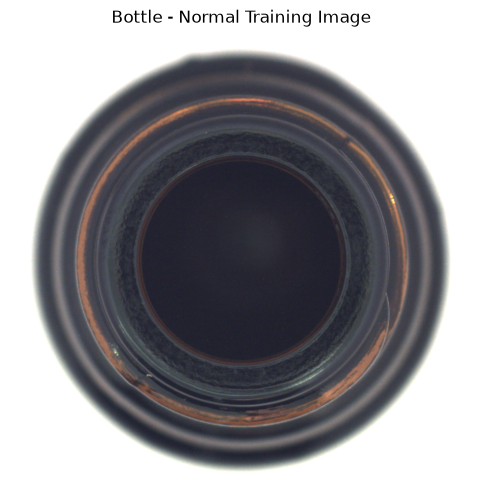

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Bottle - Normal Training Image")
plt.show()

In [3]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

image_tensor = transform(image)

print("Tensor shape:", image_tensor.shape)
print("Minimum:", image_tensor.min().item())
print("Maximum:", image_tensor.max().item())

Tensor shape: torch.Size([3, 256, 256])
Minimum: 0.12156862765550613
Maximum: 1.0


In [4]:
import sys

sys.path.append(r"X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect")

from src.data.dataset_loader import MVTecDataset

dataset = MVTecDataset(
    dataset_root=r"X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection",
    category="bottle"
)

print("Number of images:", len(dataset))

image_tensor = dataset[0]

print("Tensor shape:", image_tensor.shape)
print("Minimum:", image_tensor.min().item())
print("Maximum:", image_tensor.max().item())

Number of images: 209
Tensor shape: torch.Size([3, 256, 256])
Minimum: 0.12156862765550613
Maximum: 1.0


In [5]:
from src.data.dataset_loader import MVTecDataset

dataset = MVTecDataset(
    dataset_root=r"X:\VScode\Artificial_intelligence_n_Machine_learning\VisionInspect\dataset\mvtec_anomaly_detection",
    category="bottle"
)

image_tensor = dataset[0]

print("Number of images:", len(dataset))
print("Tensor shape:", image_tensor.shape)
print("Minimum:", image_tensor.min().item())
print("Maximum:", image_tensor.max().item())

Number of images: 209
Tensor shape: torch.Size([3, 256, 256])
Minimum: 0.12156862765550613
Maximum: 1.0


In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

images = next(iter(train_loader))

print("Batch shape:", images.shape)

Batch shape: torch.Size([16, 3, 256, 256])


In [7]:
import torch

from src.models.autoencoder import Autoencoder

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

# Take one batch from our DataLoader
images = next(iter(train_loader)).to(device)

# Run the images through the autoencoder
with torch.no_grad():
    reconstructed = model(images)

print("Input shape:", images.shape)
print("Output shape:", reconstructed.shape)
print("Device:", images.device)

Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 3, 256, 256])
Device: cuda:0


In [8]:
import torch
from src.detection.anomaly_score import reconstruction_loss

# Create two simple test images
original = torch.zeros(1, 3, 256, 256)
reconstructed = torch.zeros(1, 3, 256, 256)

loss = reconstruction_loss(original, reconstructed)

print("Reconstruction loss:", loss.item())

Reconstruction loss: 0.0


In [9]:
import torch

from torch.utils.data import DataLoader

from src.data.dataset_loader import MVTecDataset
from src.models.autoencoder import Autoencoder
from src.detection.anomaly_score import reconstruction_loss


# Project and dataset paths
DATASET_ROOT = (
    r"X:\VScode\Artificial_intelligence_n_Machine_learning"
    r"\VisionInspect\dataset\mvtec_anomaly_detection"
)


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# Dataset
dataset = MVTecDataset(
    dataset_root=DATASET_ROOT,
    category="bottle"
)


# DataLoader
train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)


# Autoencoder
model = Autoencoder().to(device)


# Get one batch
images = next(iter(train_loader)).to(device)


# Reconstruct images
with torch.no_grad():
    reconstructed = model(images)


# Calculate reconstruction loss
loss = reconstruction_loss(
    images,
    reconstructed
)


print("Input shape:", images.shape)
print("Output shape:", reconstructed.shape)
print("Reconstruction loss:", loss.item())


Device: cuda
Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 3, 256, 256])
Reconstruction loss: 0.13037776947021484
